<h1> Análise Exploratória de Dados </h1>
Objetivo: Explorar detalhadamente a base de interações que representa tentativas que o cliente fez perante a negociação ou promessa de pagamento. </br>
Entrada: interações.
Saída: relatório respondendo várias questões como, por exemplo: </br>
1 - Qual a quantidade de interações por cliente? </br>
2 - Qual a quantidade mínima, média, máximo de interações (estudo descritivo) por cliente independemente do resultado final? </br>
3 - Quais são as categorias de resultado e o percentual de distribuição de cada um deles ao longo da base?

<h3> Importação de pacotes e bibliotecas </h3>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from matplotlib.ticker import FuncFormatter
#from ydata_profiling import ProfileReport
# import loguru # Configuracao de login da plataforma

<h3> Definição de Métodos e Funções </h3>

In [25]:
def gerar_bar_plot_percentual(x, y, titulo, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(12, 6))

    cores = plt.cm.Blues(np.linspace(0.45, 0.9, len(x)))

    bars = ax.bar(x, y, color=cores)

    for bar, valor in zip(bars, y):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{valor:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10
        )

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_ylim(0, 100)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [26]:
def plot_barras_duplas(
    df,
    coluna_categoria,
    coluna_valor_1,
    coluna_valor_2,
    nome_valor_1='Grupo 1',
    nome_valor_2='Grupo 2',
    titulo='Comparação',
    ylabel='Percentual (%)',
    figsize=(12, 6),
    rotacao_x=45
):
    """
    Plota gráfico de barras duplas agrupadas.

    Parâmetros:
    ----------
    df : DataFrame
        DataFrame contendo as categorias e os dois valores.

    coluna_categoria : str
        Coluna usada no eixo X.

    coluna_valor_1 : str
        Coluna com os valores da primeira barra.

    coluna_valor_2 : str
        Coluna com os valores da segunda barra.

    nome_valor_1 : str
        Nome exibido na legenda para a primeira barra.

    nome_valor_2 : str
        Nome exibido na legenda para a segunda barra.

    titulo : str
        Título do gráfico.

    ylabel : str
        Nome do eixo Y.

    figsize : tuple
        Tamanho da figura.

    rotacao_x : int
        Rotação dos rótulos do eixo X.
    """

    x = range(len(df))
    largura = 0.4

    fig, ax = plt.subplots(figsize=figsize)

    barras_1 = ax.bar(
        [i - largura / 2 for i in x],
        df[coluna_valor_1],
        width=largura,
        label=nome_valor_1
    )

    barras_2 = ax.bar(
        [i + largura / 2 for i in x],
        df[coluna_valor_2],
        width=largura,
        label=nome_valor_2
    )

    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel(coluna_categoria)
    ax.set_ylabel(ylabel)

    ax.set_xticks(list(x))
    ax.set_xticklabels(
        df[coluna_categoria],
        rotation=rotacao_x,
        ha='right'
    )

    ax.legend()

    # Valores sobre as barras
    ax.bar_label(
        barras_1,
        fmt='%.1f%%',
        padding=3
    )

    ax.bar_label(
        barras_2,
        fmt='%.1f%%',
        padding=3
    )

    ax.grid(
        axis='y',
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

In [27]:
def gerar_barh_plot(x, y, titulo, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Paleta de azuis
    cores = plt.cm.Blues(np.linspace(0.45, 0.9, len(x)))

    bars = ax.barh(x, y, color=cores)

    # Formatação dos números no padrão brasileiro
    def formato_brasileiro(valor, pos=None):
        return (
            f'{valor:,.0f}'
            .replace(',', 'X')
            .replace('.', ',')
            .replace('X', '.')
        )

    ax.xaxis.set_major_formatter(
        FuncFormatter(formato_brasileiro)
    )

    # Percentual sobre o total
    total = y.sum()

    for bar, valor in zip(bars, y):
        percentual = valor / total * 100

        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f' {formato_brasileiro(valor)} ({percentual:.1f}%)',
            ha='left',
            va='center',
            fontsize=10
        )

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [28]:
def gerar_bar_plot(x, y, titulo, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Paleta de azuis
    cores = plt.cm.Blues(np.linspace(0.45, 0.9, len(x)))

    bars = ax.bar(x, y, color=cores)

    # Formatação dos números no padrão brasileiro
    def formato_brasileiro(valor, pos=None):
        return f'{valor:,.0f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

    ax.yaxis.set_major_formatter(
        FuncFormatter(formato_brasileiro)
    )

    # Valor absoluto sobre cada barra
    for bar, valor in zip(bars, y):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            formato_brasileiro(valor),
            ha='center',
            va='bottom',
            fontsize=10
        )

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [29]:
def gerar_relatorio_analitico_yprofiling(base,titulo,arq_html_salvar):
    try:
        profile = ProfileReport(
            base,
            title=titulo,
            explorative=True
        )
        profile.to_file(arq_html_salvar)
    except Exception as excecao:
        print(f"Erro ao gerar o relatório {excecao}")
    else:
        print(f"Relatório gerado com sucesso!")

In [31]:
def ler_base_por_csv(caminho_arquivo):
    """
    Lê um arquivo CSV e retorna um DataFrame do Pandas.
    """
    try:
        base_dataframe = pd.read_csv(caminho_arquivo)
        print(f"Arquivo lido com sucesso")
        return base_dataframe
    except Exception as excecao:
        print(f"Erro ao ler o arquivo: {excecao}")
        return None

In [32]:
def gerar_grafico_pizza(sizes,labels,titulo):
    colors = plt.cm.Blues(np.linspace(0.3, 0.7, len(sizes)))
    plt.figure(figsize=(6,6))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
    plt.title(titulo)
    plt.show()

In [33]:
def gerar_histograma(
    dados,
    titulo,
    xlabel,
    ylabel,
    bins_qtde=10
):
    # Remover valores nulos
    dados = dados.dropna()

    # Média e desvio padrão
    media = dados.mean()
    desvio_padrao = dados.std()

    # Paleta de cores
    colors = plt.cm.Blues(
        np.linspace(0.3, 0.8, bins_qtde)
    )

    # Criando a figura
    plt.figure(figsize=(8, 6))

    # Histograma
    n, bins, patches = plt.hist(
        dados,
        bins=bins_qtde,
        edgecolor="black",
        density=True
    )

    # Aplicando cores às barras
    for i, patch in enumerate(patches):
        patch.set_facecolor(colors[i])

    # -----------------------------
    # Curva de distribuição normal
    # -----------------------------

    x = np.linspace(
        dados.min(),
        dados.max(),
        1000
    )

    curva_normal = norm.pdf(
        x,
        media,
        desvio_padrao
    )

    plt.plot(
        x,
        curva_normal,
        linewidth=2,
        label=f"Distribuição Normal\nMédia = {media:,.0f}"
    )

    # Título e rótulos
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Legenda
    plt.legend()

    # Remover notação científica
    plt.ticklabel_format(
        style="plain",
        axis="x",
        useOffset=False
    )

    plt.tight_layout()
    plt.show()

In [34]:
def gerar_box_plot(dados, titulo, ylabel):

    plt.figure(figsize=(8, 6))

    plt.boxplot(
        dados.dropna(),
        patch_artist=True,
        boxprops=dict(
            facecolor="lightblue",
            color="blue"
        ),
        medianprops=dict(
            color="red"
        )
    )

    plt.title(titulo)
    plt.ylabel(ylabel)

    # Formatação brasileira dos valores
    def formato_brasileiro(valor, pos):
        return f"{valor:,.0f}".replace(",", ".")

    plt.gca().yaxis.set_major_formatter(
        FuncFormatter(formato_brasileiro)
    )

    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [35]:
def gerar_grafico_linhas(eixo_tempo, eixo_valores,title,xlabel,ylabel):    
    # Gerando o gráfico de linha
    plt.figure(figsize=(10, 6))
    plt.plot(eixo_tempo, eixo_valores, marker='o', linestyle='-', color='b')

    # Adicionando título e rótulos aos eixos
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.fill_between(eixo_tempo, eixo_valores, color='skyblue', alpha=0.4)

    # Exibindo o gráfico
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [36]:
def gerar_box_plot(dados, titulo, ylabel):

    plt.figure(figsize=(8, 6))

    plt.boxplot(
        dados.dropna(),
        patch_artist=True,
        boxprops=dict(
            facecolor="lightblue",
            color="blue"
        ),
        medianprops=dict(
            color="red"
        )
    )

    plt.title(titulo)
    plt.ylabel(ylabel)

    # Remover notação científica do eixo Y
    plt.ticklabel_format(
        style="plain",
        axis="y",
        useOffset=False
    )

    plt.grid(True)

    plt.tight_layout()
    plt.show()

<h3> Definição do Escopo Principal(Main) </h3>

<h3> Base de Clientes Tratada </h3>

VARÍAVEL [TARGET] x [CATEGÓRICAS]

<h4> 1. Relembrando a TARGET. Como está a distribuição dos clientes que regularizaram dentro dos 30 dias? Variável categórica nominal. </h4>

In [13]:
# Carregando a base de dados
caminho_base__clientes = "../bases_tratadas/clientes_sem_nulos.csv"
clientes_sem_nulos = ler_base_por_csv(caminho_base__clientes)
print(f"Qtde de linhas: {len(clientes_sem_nulos)}")
print(f"Qtde de colunas: {len(clientes_sem_nulos.columns)}")
print(f"Colunas: {clientes_sem_nulos.columns}")

Arquivo lido com sucesso
Qtde de linhas: 800
Qtde de colunas: 26
Colunas: Index(['id_cliente', 'data_referencia', 'setor', 'porte', 'uf',
       'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
       'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
       'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
       'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
       'renegociacoes_ult_12m', 'canal_preferencial', 'risco_setorial',
       'score_regularizacao_legado', 'score_cobranca_atualizado_30d',
       'regularizou_30d', 'ano_referencia', 'mes_referencia', 'dia_referencia',
       'ano_mes_referencia', 'nome_mes_referencia'],
      dtype='object')


In [14]:
print(f"Existem atualmmente {len(clientes_sem_nulos)} registros na base de clientes")
print(f"Existem atualmmente {len(clientes_sem_nulos['id_cliente'].unique())} clientes únicos na base dado id_cliente")
print(f"Percentual de registros duplicados: {round((len(clientes_sem_nulos) - len(clientes_sem_nulos['id_cliente'].unique())) / len(clientes_sem_nulos) * 100, 2)}%")

Existem atualmmente 800 registros na base de clientes
Existem atualmmente 800 clientes únicos na base dado id_cliente
Percentual de registros duplicados: 0.0%


In [15]:
# Carregando a base de dados de interaçòes
caminho_base_interacoes = "../interacoes.csv"
interacoes = ler_base_por_csv(caminho_base_interacoes)
print(f"Qtde de linhas: {len(interacoes)}")
print(f"Qtde de colunas: {len(interacoes.columns)}")
print(f"Colunas: {interacoes.columns}")

Arquivo lido com sucesso
Qtde de linhas: 2379
Qtde de colunas: 7
Colunas: Index(['id_interacao', 'id_cliente', 'data_interacao', 'canal', 'direcao',
       'resultado', 'texto'],
      dtype='object')


In [16]:
interacoes.sample(2)

,id_interacao,id_cliente,data_interacao,canal,direcao,resultado,texto
2125,INT002128,PJ0718,2025-11-14,whatsapp,ativa,promessa_registrada,Promessa de pagamento registrada para os próxi...
808,INT000810,PJ0275,2025-12-10,whatsapp,ativa,dificuldade_temporaria,Cliente relatou queda temporária de faturament...


<h4> 1. Existem quantas interações distintas e o percentual delas sobre a base inteira? </h4>

In [18]:
print(f"Existem atualmmente {len(interacoes)} registros na base de interações")
print(f"Existem atualmmente {len(interacoes['id_interacao'].unique())} interações únicas")
print(f"Percentual de registros duplicados: {round((len(interacoes) - len(interacoes['id_interacao'].unique())) / len(interacoes) * 100, 2)}%")

Existem atualmmente 2379 registros na base de interações
Existem atualmmente 2379 interações únicas
Percentual de registros duplicados: 0.0%


Cada linha representa uma interação de forma única, sem duplicidade.

<h4> 2. Quantos clientes distintos e o percentual delas sobre a base inteira? </h4>

In [19]:
print(f"Existem atualmmente {len(interacoes)} clientes na base de interações")
print(f"Existem atualmmente {len(interacoes['id_cliente'].unique())} clientes únicos")
print(f"Percentual de registros duplicados: {round((len(interacoes) - len(interacoes['id_cliente'].unique())) / len(interacoes) * 100, 2)}%")

Existem atualmmente 2379 clientes na base de interações
Existem atualmmente 800 clientes únicos
Percentual de registros duplicados: 66.37%


Isso mostra que um único cliente pode ter várias interações, o que faz sentido no ponto de vista de negócio. Vamos visulizar um cliente com várias interações.

In [21]:
interacoes.head(10)
# Note que o cliente PJ0001 teve 5 interações nos variados canais e datas diferentes.

,id_interacao,id_cliente,data_interacao,canal,direcao,resultado,texto
0,INT000005,PJ0001,2025-12-23,whatsapp,ativa,sem_sucesso,E-mail devolvido; necessário validar o endereç...
1,INT000002,PJ0001,2026-01-07,telefone,ativa,sem_sucesso,"Mensagem enviada no canal autorizado, ainda se..."
2,INT000003,PJ0001,2026-01-21,whatsapp,ativa,intencao_pagamento,Cliente reconheceu o débito e solicitou prazo ...
3,INT000001,PJ0001,2026-02-04,email,ativa,sem_sucesso,"Mensagem enviada no canal autorizado, ainda se..."
4,INT000004,PJ0001,2026-02-27,telefone,ativa,promessa_registrada,Promessa de pagamento registrada para os próxi...
5,INT000006,PJ0002,2025-12-23,whatsapp,receptiva,intencao_pagamento,Cliente reconheceu o débito e solicitou prazo ...
6,INT000008,PJ0002,2026-01-25,telefone,ativa,intencao_pagamento,Representante confirmou intenção de pagamento ...
7,INT000007,PJ0002,2026-01-28,telefone,ativa,recusa_oferta,Cliente considerou a parcela acima da capacida...
8,INT000009,PJ0003,2026-01-01,telefone,ativa,promessa_registrada,Cliente confirmou data e valor para pagamento ...
9,INT000011,PJ0004,2025-11-24,whatsapp,receptiva,sem_sucesso,E-mail devolvido; necessário validar o endereç...


Features interessantes: quantidade de tentativas, quantidade de acordos que deram certos (houve promessa) etc.

<h4> 3. Quais são os canais disponíveis? Percentual de cada um deles? </h4>

In [22]:
print(f"""
Qtde de canais únicos: {interacoes['canal'].nunique()}
canais presentes: {interacoes['canal'].unique()}
""")


Qtde de canais únicos: 4
canais presentes: ['whatsapp' 'telefone' 'email' 'portal']



In [23]:
distribuicao_canal = (
    interacoes.groupby("canal")["id_cliente"]
    .nunique()
    .reset_index(name="clientes_unicos")
)

# Percentual
total_clientes = interacoes["id_cliente"].nunique()

distribuicao_canal["percentual"] = (
    distribuicao_canal["clientes_unicos"]
    / total_clientes
    * 100
)

# Ordenar do maior para o menor
distribuicao_canal = distribuicao_canal.sort_values(
    "percentual",
    ascending=False
)

print(distribuicao_canal)

      canal  clientes_unicos  percentual
3  whatsapp              519      64.875
2  telefone              472      59.000
0     email              408      51.000
1    portal              256      32.000


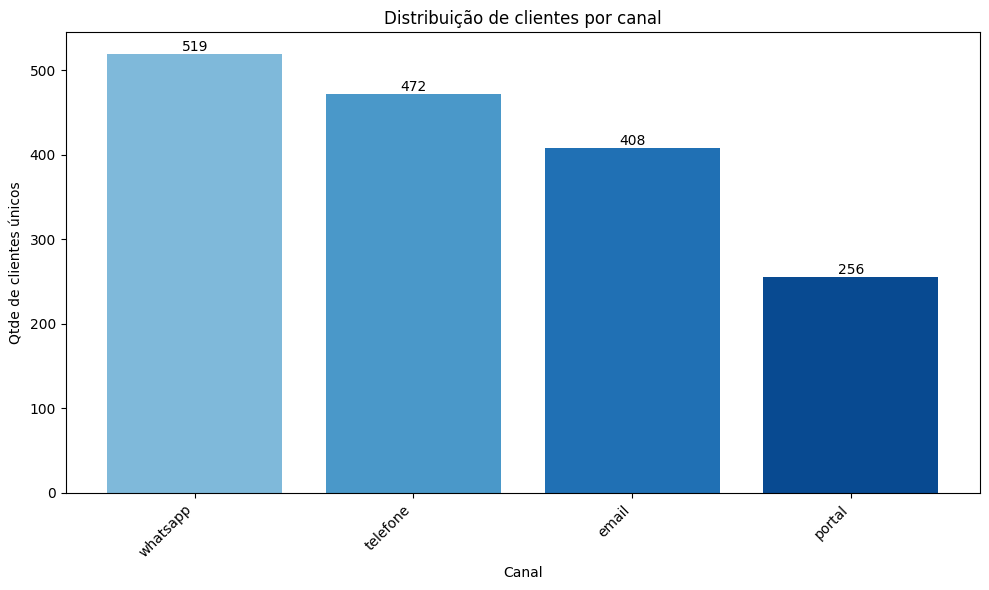

In [38]:
gerar_bar_plot(distribuicao_canal.canal,
               distribuicao_canal.clientes_unicos,
               "Distribuição de clientes por canal","Canal","Qtde de clientes únicos")

<h4> 4. Quantas direções existem? Porcentual de cada uma delas sobre a base inteira? </h4>

In [39]:
print(f"""
Qtde de direcao únicos: {interacoes['direcao'].nunique()}
direcao presentes: {interacoes['direcao'].unique()}
""")


Qtde de direcao únicos: 2
direcao presentes: ['ativa' 'receptiva']



In [40]:
interacoes['direcao'].value_counts()

direcao
ativa        1846
receptiva     533
Name: count, dtype: int64

In [41]:
interacoes['direcao'].value_counts(normalize = True)

direcao
ativa        0.775956
receptiva    0.224044
Name: proportion, dtype: float64

<h4> 5. Quantos resultados distintos existem? Percentual de cada um deles?</h4>

In [42]:
interacoes['resultado'].value_counts()

resultado
sem_sucesso               709
intencao_pagamento        509
dificuldade_temporaria    449
promessa_registrada       350
recusa_oferta             228
contestacao               112
recuperacao_judicial       22
Name: count, dtype: int64

In [43]:
interacoes['resultado'].value_counts(normalize = True)

resultado
sem_sucesso               0.298024
intencao_pagamento        0.213955
dificuldade_temporaria    0.188735
promessa_registrada       0.147121
recusa_oferta             0.095839
contestacao               0.047079
recuperacao_judicial      0.009248
Name: proportion, dtype: float64

In [44]:
distribuicao_resultado = (
    interacoes.groupby("resultado")["id_cliente"]
    .nunique()
    .reset_index(name="clientes_unicos")
)

# Percentual
total_clientes = interacoes["id_cliente"].nunique()

distribuicao_resultado["percentual"] = (
    distribuicao_resultado["clientes_unicos"]
    / total_clientes
    * 100
)

# Ordenar do maior para o menor
distribuicao_resultado = distribuicao_resultado.sort_values(
    "percentual",
    ascending=False
)

print(distribuicao_resultado)

                resultado  clientes_unicos  percentual
6             sem_sucesso              484      60.500
2      intencao_pagamento              388      48.500
1  dificuldade_temporaria              344      43.000
3     promessa_registrada              285      35.625
5           recusa_oferta              199      24.875
0             contestacao              105      13.125
4    recuperacao_judicial               22       2.750


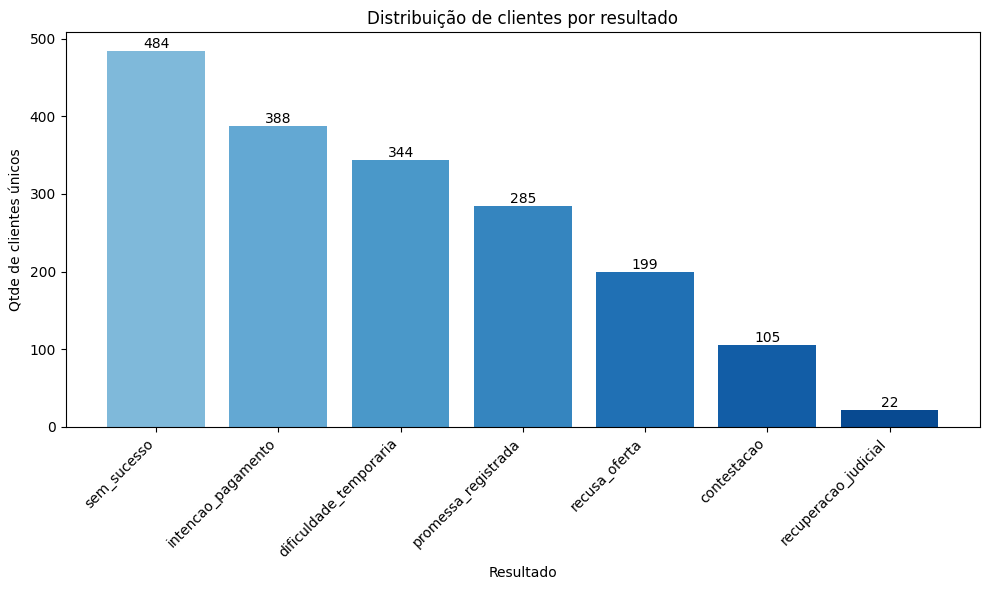

In [46]:
gerar_bar_plot(distribuicao_resultado.resultado,
               distribuicao_resultado.clientes_unicos,
               "Distribuição de clientes por resultado","Resultado","Qtde de clientes únicos")

<h4> 6. Derivando a DATA. Qual foi o período histórico das interações dos clientes? </h4>

In [47]:
interacoes['data_interacao'] = pd.to_datetime(
    interacoes['data_interacao']
)

# AAAA-MM
interacoes['ano_mes_interacao'] = (
    interacoes['data_interacao']
    .dt.strftime('%Y-%m')
)

# Nome do mês por extenso
meses_pt = {
    1: 'Janeiro',
    2: 'Fevereiro',
    3: 'Março',
    4: 'Abril',
    5: 'Maio',
    6: 'Junho',
    7: 'Julho',
    8: 'Agosto',
    9: 'Setembro',
    10: 'Outubro',
    11: 'Novembro',
    12: 'Dezembro'
}

interacoes['nome_mes_interacao'] = (
    interacoes['data_interacao']
    .dt.month
    .map(meses_pt)
)

In [49]:
interacoes[['nome_mes_interacao','data_interacao','ano_mes_interacao']].sample(5)

,nome_mes_interacao,data_interacao,ano_mes_interacao
722,Novembro,2025-11-15,2025-11
380,Junho,2026-06-09,2026-06
1390,Janeiro,2026-01-22,2026-01
909,Janeiro,2026-01-06,2026-01
934,Janeiro,2026-01-30,2026-01


In [51]:
# Quantidade de anos distintos
qtd_anos = interacoes['data_interacao'].dt.year.nunique()

# Quantidade de meses distintos
qtd_meses = interacoes['ano_mes_interacao'].nunique()

# Data mínima
data_minima = interacoes['data_interacao'].min()

# Data máxima
data_maxima = interacoes['data_interacao'].max()

print(f'Quantidade de anos: {qtd_anos}')
print(f'Quantidade de meses: {qtd_meses}')
print(f'Data mínima: {data_minima.strftime("%d/%m/%Y")}')
print(f'Data máxima: {data_maxima.strftime("%d/%m/%Y")}')

Quantidade de anos: 2
Quantidade de meses: 8
Data mínima: 14/11/2025
Data máxima: 29/06/2026


In [52]:
# Quantidade de interações por ano-mês
interacoes_por_mes = (
    interacoes
    .groupby('ano_mes_interacao')
    .size()
    .reset_index(name='qtd_interacoes')
    .sort_values('ano_mes_interacao')
)

interacoes_por_mes

,ano_mes_interacao,qtd_interacoes
0,2025-11,64
1,2025-12,254
2,2026-01,417
3,2026-02,406
4,2026-03,391
5,2026-04,384
6,2026-05,300
7,2026-06,163


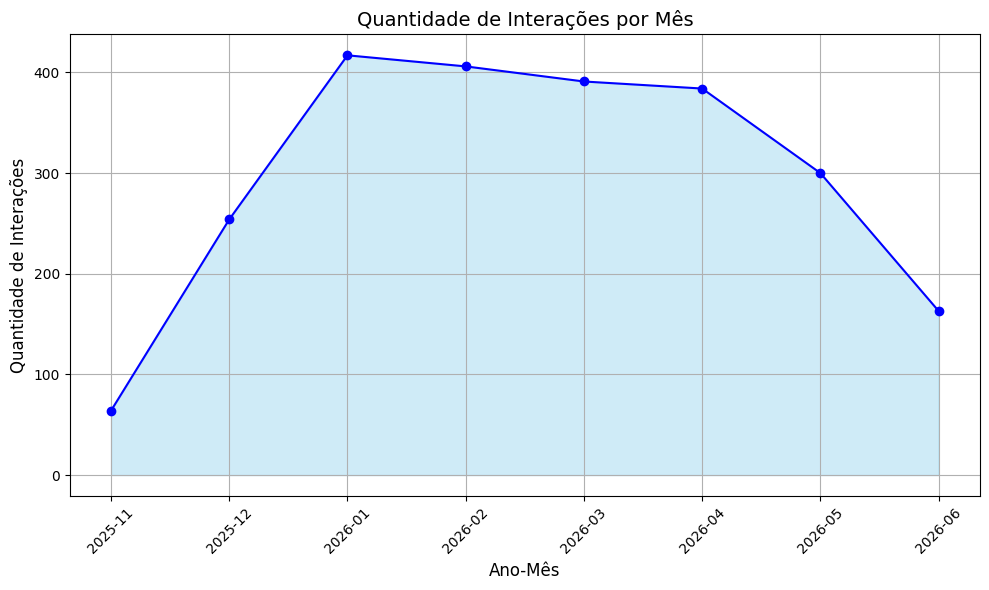

In [53]:
gerar_grafico_linhas(
    eixo_tempo=interacoes_por_mes['ano_mes_interacao'],
    eixo_valores=interacoes_por_mes['qtd_interacoes'],
    title='Quantidade de Interações por Mês',
    xlabel='Ano-Mês',
    ylabel='Quantidade de Interações'
)

O período que teve maior quantidade de interações foi em 2026-01, seguido de 2026-02 e 2026-05.

<h4> 7. Quantos interações tiveram os clientes, independente do resultado final (promessa de pagamento, sem sucesso etc)? </h4>

In [55]:
interacoes.sample(1)

,id_interacao,id_cliente,data_interacao,canal,direcao,resultado,texto,ano_mes_interacao,nome_mes_interacao
598,INT000599,PJ0205,2026-02-24,email,ativa,sem_sucesso,Tentativa sem sucesso; telefone chamou e não h...,2026-02,Fevereiro


In [56]:
interacoes_por_cliente = (
    interacoes
    .groupby('id_cliente')
    .size()
    .reset_index(name='qtd_interacoes')
    .sort_values('qtd_interacoes', ascending=False)
)

interacoes_por_cliente

,id_cliente,qtd_interacoes
0,PJ0001,5
320,PJ0321,5
325,PJ0326,5
329,PJ0330,5
344,PJ0345,5
...,...,...
432,PJ0433,1
183,PJ0184,1
75,PJ0076,1
658,PJ0659,1


In [57]:
interacoes_por_cliente['qtd_interacoes'].describe()

count    800.000000
mean       2.973750
std        1.437234
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: qtd_interacoes, dtype: float64

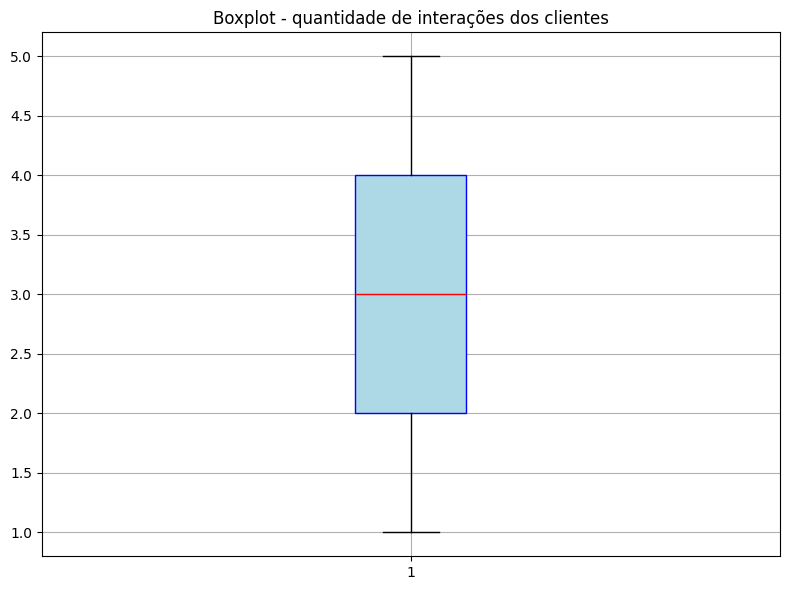

In [58]:
gerar_box_plot(interacoes_por_cliente['qtd_interacoes'],
               "Boxplot - quantidade de interações dos clientes", 
               "")

<h4> 8. Verificando a existência de valores nulos </h4>

In [60]:
interacoes.isnull().sum()

id_interacao          0
id_cliente            0
data_interacao        0
canal                 0
direcao               0
resultado             0
texto                 0
ano_mes_interacao     0
nome_mes_interacao    0
dtype: int64

In [ ]:
# Salvando o arquivo final
try:
    interacoes.to_csv(
        "../bases_tratadas/interacoes_com_info_data.csv",
        index=False,
        encoding="utf-8-sig"
    )
except Exception as excecao:
    print(f"Ouve um erro ao salvar o arquivo {excecao}")
else:
    print(f"Arquivo salvo com sucesso.")

Arquivo salvo com sucesso.


<h4> Sabemos que temos entre 1 - 5 interações, mas com quanto tempo (dias, semanas ou meses) elas acontecem para definirmos [A JANELA DE TEMPO]? </h4>

In [62]:
#Intervalo entre interações do mesmo cliente
interacoes['data_interacao'] = pd.to_datetime(interacoes['data_interacao'])

interacoes = interacoes.sort_values(
    ['id_cliente', 'data_interacao']
)

interacoes['dias_desde_interacao_anterior'] = (
    interacoes
    .groupby('id_cliente')['data_interacao']
    .diff()
    .dt.days
)

In [ ]:
# 1 - 69 dias
interacoes['dias_desde_interacao_anterior'].describe()

count    1579.000000
mean       15.575681
std        13.310128
min         0.000000
25%         5.000000
50%        12.000000
75%        22.000000
max        69.000000
Name: dias_desde_interacao_anterior, dtype: float64

In [ ]:
#7, 14, 30, 60 e 90 dias. 30 DIAS COMO PRIMEIRO CANDIDATA

Os intervalos entre interações apresentam mediana de 12 dias e terceiro quartil de 22 dias, indicando que as interações tendem a ocorrer em intervalos relativamente curtos. Como 75% dos intervalos estão concentrados em até 22 dias, uma janela histórica de 30 dias surge como uma candidata adequada para construção das features de interação. Entretanto, a escolha definitiva deve ser validada comparando a quantidade de interações capturadas e o poder preditivo das janelas de 7, 14, 30, 60 e 90 dias em relação à regularizou_30d.